In [1]:
import matplotlib.pyplot as plt
from algorithms.tss_file import TSSFile
import os

In [2]:
def find_file(filename, search_dir):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return root
    return None

In [3]:
folder = r'C:\Users\FeiyuanYang\Downloads'
tss_file = 'HB1_BY71_0Vd_500kHz_400ns_15Vg_15R2Rg_RT.tss'
path = find_file(tss_file, folder)
tss = TSSFile(path, tss_file, source='Local')
channel_labels = tss.channel_labels
num = len(channel_labels.keys())
print(channel_labels)

{'ch1': 'Vg', 'ch2': 'Vgi', 'ch3': 'Vd', 'ch4': 'Vdd8', 'ch5': 'Vghs'}


c:\Users\FeiyuanYang\OneDrive - Cambridge GaN Devices Ltd\Documents\CGD_codes\DP_Algorithm-main\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


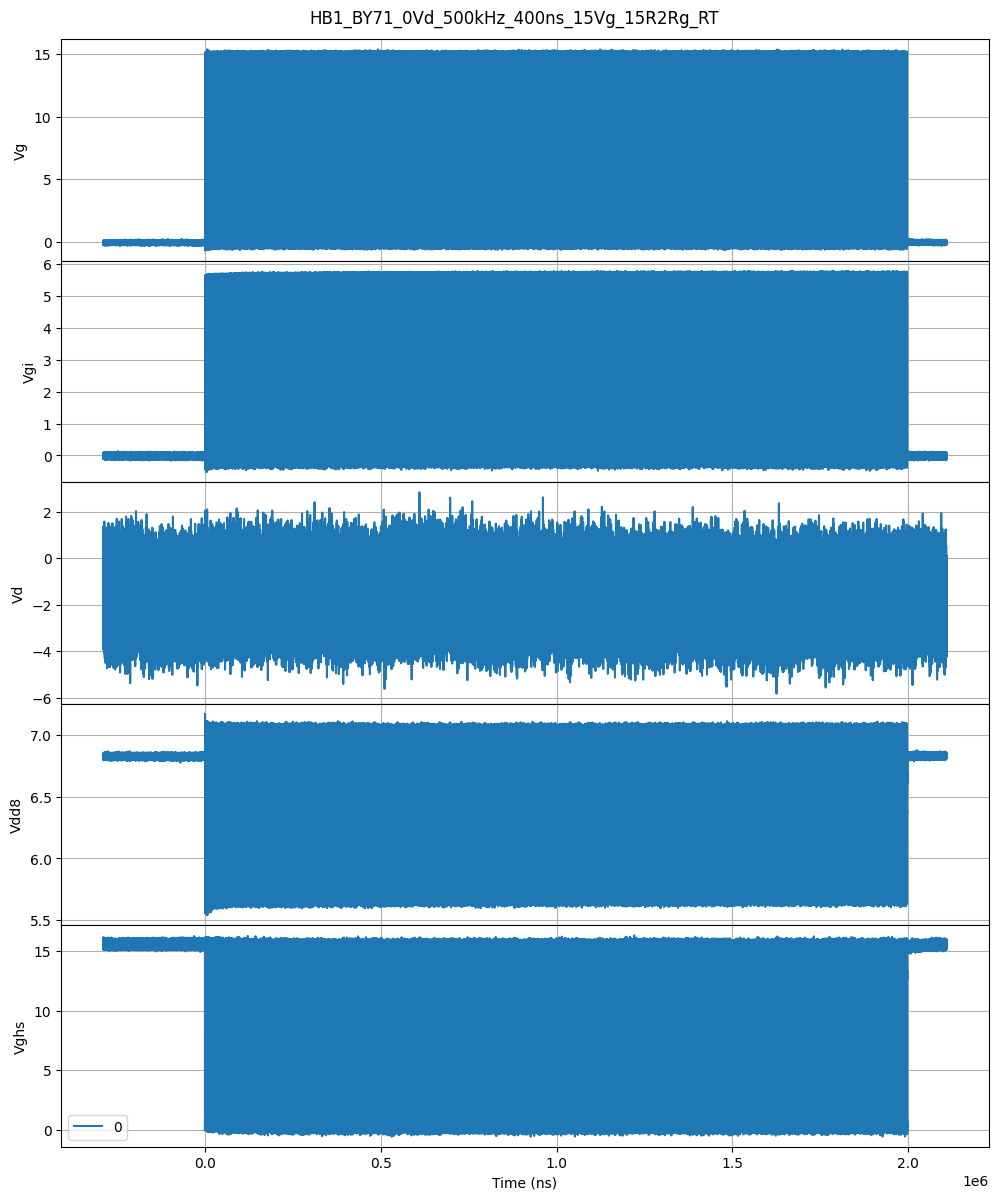

In [4]:
fig, axs = plt.subplots(num, 1, sharex=True, figsize=(10, 12))
fig.suptitle(tss_file[:-4])
fig.tight_layout()
fig.subplots_adjust(hspace=0)
time1 = tss.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9

index = 0
for i in [0]:
    index = 0
    for channel in channel_labels.keys():
        values = tss.waveforms[channel].values_for_frame(i)
        axs[index].plot(time1, values, label=i)
        axs[index].set_ylabel(channel_labels[channel])
        axs[index].grid(True)
        index += 1

plt.legend()
plt.xlabel('Time (ns)')
#plt.xlim([500, 1300])
#plt.legend(loc='best')
plt.show()